# 02 — Aprendizado não supervisionado com K-Means

O K-Means agrupa transações semelhantes sem utilizar rótulos prévios. O modelo usa somente três características não redundantes:

- `money`: valor da compra após normalização min-max;
- `hour`: hora da transação;
- `is_weekend`: indicador de fim de semana.

`weekday` e `day_period` foram excluídos porque repetem informações já representadas por `is_weekend` e `hour`. `cash_type` foi excluído porque apenas 89 das 3.636 compras foram pagas em dinheiro; após padronização, essa variável rara poderia criar um grupo baseado apenas na forma de pagamento. As colunas de café são usadas somente para interpretar os grupos, evitando que o algoritmo apenas reproduza os oito produtos.

Antes do K-Means, as três características são padronizadas com `StandardScaler`, isto é, cada coluna passa a ter média 0 e desvio-padrão 1. Assim, nenhuma unidade domina a distância euclidiana.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
K_RANGE = range(2, 11)
CHOSEN_K = 3
FEATURE_COLS = ["money", "hour", "is_weekend"]
CLUSTER_ORDER = ["Dia útil — manhã", "Dia útil — tarde/noite", "Fim de semana"]
PALETTE = dict(zip(CLUSTER_ORDER, sns.color_palette("Set2", 3)))
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

df = pd.read_csv("02_normalized.csv")
coffee_cols = [column for column in df.columns if column.startswith("coffee_name_")]

assert len(df) == 3636
assert df[FEATURE_COLS].isna().sum().sum() == 0
assert df[coffee_cols].sum(axis=1).eq(1).all()

scaler = StandardScaler()
X = scaler.fit_transform(df[FEATURE_COLS])
pd.DataFrame(X, columns=FEATURE_COLS).agg(["mean", "std"]).round(3)

,money,hour,is_weekend
mean,-0.0,0.0,-0.0
std,1.0,1.0,1.0


## Escolha do número de clusters

A curva do cotovelo compara a inércia, ou soma das distâncias quadráticas dentro dos grupos, para `k` entre 2 e 10. O silhouette complementa a análise medindo coesão e separação. O projeto adota `k = 3`: há uma redução relevante da inércia até esse ponto e três grupos oferecem uma interpretação simples dos padrões de compra.

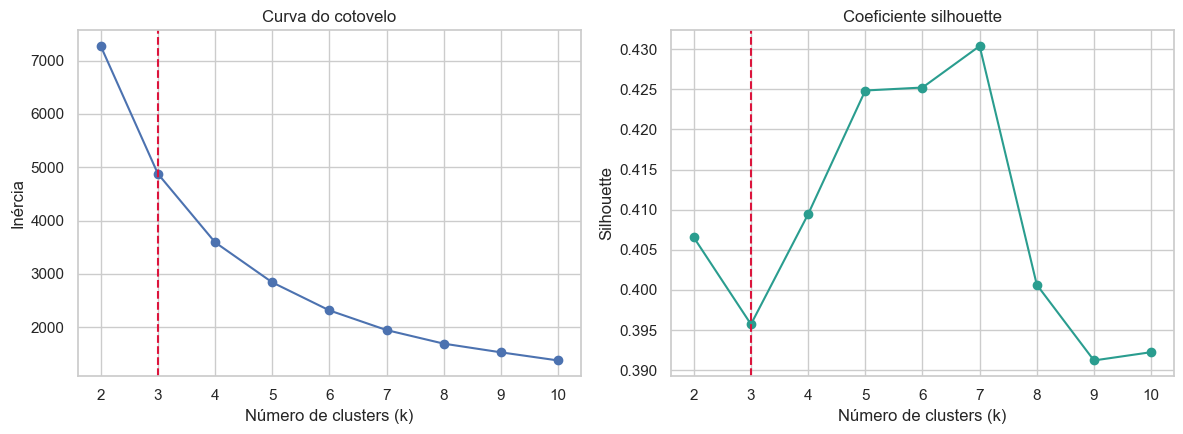

,k,inertia,silhouette
0,2,7271.450,0.407
1,3,4875.968,0.396
2,4,3591.374,0.409
3,5,2840.473,0.425
4,6,2314.471,0.425
5,7,1945.858,0.430
6,8,1691.326,0.401
7,9,1528.525,0.391
8,10,1376.301,0.392


In [2]:
metric_rows = []
for k in K_RANGE:
    candidate = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    candidate_labels = candidate.fit_predict(X)
    metric_rows.append(
        {
            "k": k,
            "inertia": candidate.inertia_,
            "silhouette": silhouette_score(X, candidate_labels),
        }
    )

metrics = pd.DataFrame(metric_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(metrics["k"], metrics["inertia"], marker="o")
axes[0].axvline(CHOSEN_K, color="crimson", linestyle="--", linewidth=1.5)
axes[0].set_title("Curva do cotovelo")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inércia")
axes[0].set_xticks(list(K_RANGE))

axes[1].plot(metrics["k"], metrics["silhouette"], marker="o", color="#2A9D8F")
axes[1].axvline(CHOSEN_K, color="crimson", linestyle="--", linewidth=1.5)
axes[1].set_title("Coeficiente silhouette")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette")
axes[1].set_xticks(list(K_RANGE))

fig.tight_layout()
fig.savefig(FIGURE_DIR / "curva_cotovelo.png", dpi=160, bbox_inches="tight")
plt.show()
metrics.round(3)

In [3]:
kmeans = KMeans(n_clusters=CHOSEN_K, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans.fit_predict(X)


def cluster_name(group: pd.DataFrame) -> str:
    if group["is_weekend"].mean() >= 0.5:
        return "Fim de semana"
    if group["hour"].mean() < 14:
        return "Dia útil — manhã"
    return "Dia útil — tarde/noite"


name_by_id = {
    cluster_id: cluster_name(group)
    for cluster_id, group in df.groupby("cluster")
}
assert len(set(name_by_id.values())) == CHOSEN_K
df["cluster_name"] = df["cluster"].map(name_by_id)

summary = (
    df.groupby("cluster_name")
    .agg(
        transacoes=("cluster", "size"),
        gasto_medio=("money", "mean"),
        hora_media=("hour", "mean"),
        proporcao_fim_de_semana=("is_weekend", "mean"),
    )
    .reindex(CLUSTER_ORDER)
)
summary["proporcao"] = summary["transacoes"] / len(df)

assert summary["transacoes"].notna().all()
assert summary["transacoes"].sum() == len(df)
summary.round(3)

,transacoes,gasto_medio,hora_media,proporcao_fim_de_semana,proporcao
cluster_name,,,,,
Dia útil — manhã,1416,0.519,10.929,0.0,0.389
Dia útil — tarde/noite,1304,0.737,17.739,0.0,0.359
Fim de semana,916,0.621,14.085,1.0,0.252


## Heatmap das médias dos clusters

As anotações exibem as médias nas unidades interpretáveis: gasto normalizado, hora e proporção de compras no fim de semana. As cores representam o z-score calculado entre as médias dos três clusters, permitindo comparar características com escalas diferentes.

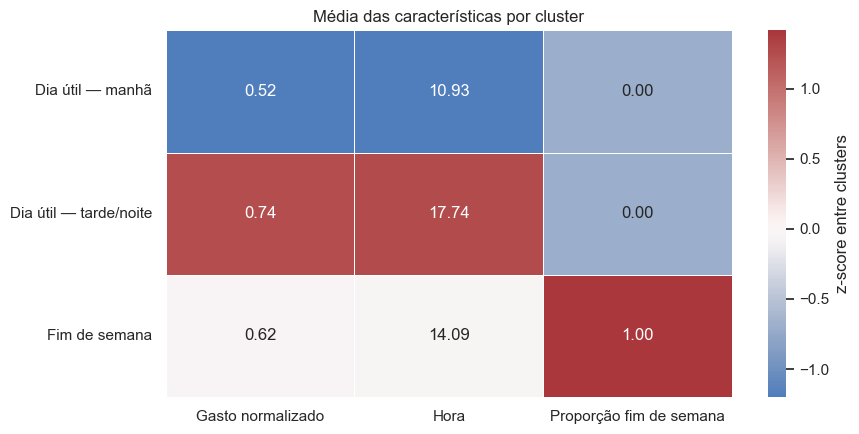

In [4]:
profile = df.groupby("cluster_name")[FEATURE_COLS].mean().reindex(CLUSTER_ORDER)
profile_z = (profile - profile.mean()) / profile.std(ddof=0)

display_profile = profile.rename(
    columns={
        "money": "Gasto normalizado",
        "hour": "Hora",
        "is_weekend": "Proporção fim de semana",
    }
)
display_profile_z = profile_z.rename(columns=dict(zip(profile.columns, display_profile.columns)))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(
    display_profile_z,
    cmap="vlag",
    center=0,
    annot=display_profile.round(2),
    fmt=".2f",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "z-score entre clusters"},
)
ax.set_title("Média das características por cluster")
ax.set_xlabel("")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "heatmap_clusters.png", dpi=160, bbox_inches="tight")
plt.show()

## Composição de cafés

As categorias de café não participaram do treinamento. O gráfico abaixo é apenas uma análise posterior para ajudar a interpretar os grupos encontrados.

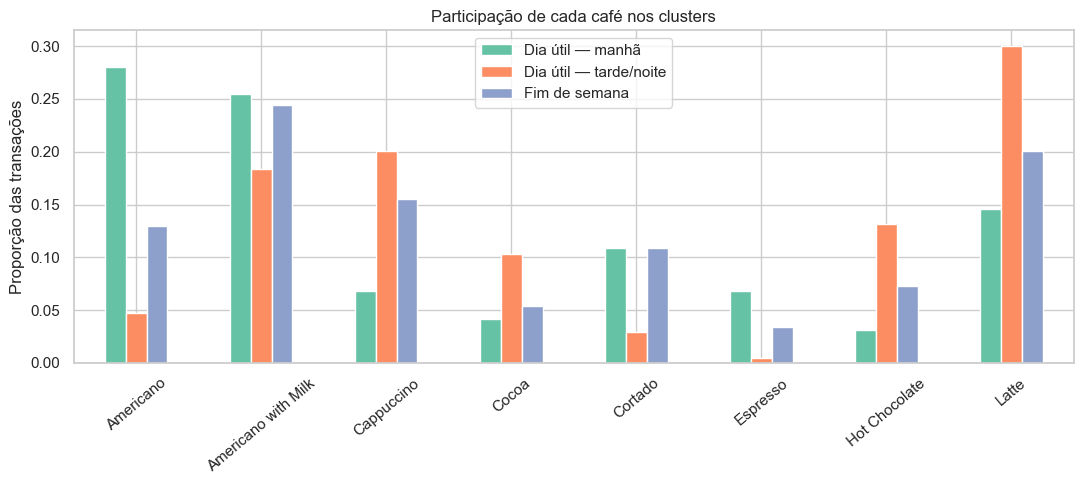

,Americano,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
cluster_name,,,,,,,,
Dia útil — manhã,0.280,0.255,0.069,0.042,0.109,0.069,0.031,0.146
Dia útil — tarde/noite,0.048,0.183,0.201,0.104,0.029,0.005,0.131,0.300
Fim de semana,0.130,0.245,0.155,0.053,0.109,0.034,0.073,0.201


In [5]:
coffee_share = (
    df.groupby("cluster_name")[coffee_cols]
    .mean()
    .reindex(CLUSTER_ORDER)
    .rename(columns=lambda column: column.replace("coffee_name_", ""))
)

fig, ax = plt.subplots(figsize=(11, 5))
coffee_share.T.plot(
    kind="bar",
    ax=ax,
    color=[PALETTE[name] for name in CLUSTER_ORDER],
)
ax.set_title("Participação de cada café nos clusters")
ax.set_xlabel("")
ax.set_ylabel("Proporção das transações")
ax.tick_params(axis="x", rotation=40)
ax.legend(title="")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "mix_cafes.png", dpi=160, bbox_inches="tight")
plt.show()
coffee_share.round(3)

## Interpretação

- **Dia útil — manhã:** compras de segunda a sexta, concentradas no início do dia e com menor gasto médio.
- **Dia útil — tarde/noite:** compras de segunda a sexta em horários mais tardios e com maior gasto médio.
- **Fim de semana:** compras realizadas aos sábados e domingos, distribuídas ao longo do horário de funcionamento.

Os nomes são descrições das médias; o K-Means recebeu apenas números e não esses rótulos.

In [6]:
output_path = Path("03_clustered.csv")
expected_columns = list(pd.read_csv("02_normalized.csv", nrows=0).columns) + ["cluster", "cluster_name"]

assert df.columns.tolist() == expected_columns
assert len(df) == 3636
assert df["cluster_name"].nunique() == 3

df.to_csv(output_path, index=False)
print(f"Arquivo salvo: {output_path} — formato {df.shape}")
df.head()

Arquivo salvo: 03_clustered.csv — formato (3636, 16)


,money,weekday,is_weekend,day_period,hour,cash_type,coffee_name_Americano,coffee_name_Americano with Milk,coffee_name_Cappuccino,coffee_name_Cocoa,coffee_name_Cortado,coffee_name_Espresso,coffee_name_Hot Chocolate,coffee_name_Latte,cluster,cluster_name
0,0.940585,4,0,1,10,0,0,0,0,0,0,0,0,1,2,Dia útil — manhã
1,0.940585,4,0,2,12,0,0,0,0,0,0,0,1,0,0,Dia útil — tarde/noite
2,0.940585,4,0,2,12,0,0,0,0,0,0,0,1,0,0,Dia útil — tarde/noite
3,0.492687,4,0,2,13,0,1,0,0,0,0,0,0,0,2,Dia útil — manhã
4,0.940585,4,0,2,13,0,0,0,0,0,0,0,0,1,0,Dia útil — tarde/noite
